# Satellite Telemetry Anomaly Detection - Exploratory Data Analysis
This notebook contains the preliminary data loading, verification, and exploratory analysis of the satellite telemetry dataset

## 1. Environment Setup

### Libraries import

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns

from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Reproducibility setup

In [10]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### Plotting configurations

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

### Data paths definitions

In [12]:
RAW_DATA_DIR = "../data"
PROCESSED_DATA_DIR = "../data/processed"

DATASET_PATH  = os.path.join(RAW_DATA_DIR, "dataset.csv")
SEGMENTS_PATH = os.path.join(RAW_DATA_DIR, "segments.csv")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

## 2. Global Features Dataset Exploration

The dataset combines a **macro-aggregated view** (segment-level statistics) with a **micro-sequential view** (high-resolution raw time-series).

### dataset.csv

* **Dimensions**: $2,123$ observations (segments) $\times$ $23$ feature columns
* **Identifiers**:
  * `channel`: Telemetry sensor ID
  * `anomaly`: Target binary label ($0 = \text{Nominal}, 1 = \text{Anomalous}$)
  * `train`: Experimental split mask ($1 = \text{Train}, 0 = \text{Test}$)
* **Structural Properties**:
  * `duration`: time-length of segments in seconds
  * `len`: sample count
  * `sampling`: rate of acquisition
* **Statistical Descriptors**:
  * Moments: `mean`, `std`, `var`, `skewness` and `kurtosis`
  * Dynamic metrics: `diff_var` and `n_peaks`

In [13]:
if os.path.exists(DATASET_PATH):
    df_dataset = pd.read_csv(DATASET_PATH)
    print("Dataset (Global Features)\n")
    print(f"Observations (Rows): {df_dataset.shape[0]}")
    print(f"Features (Columns):  {df_dataset.shape[1]}\n")
    print("Detailed Summary")
    df_dataset.info()
else:
    print(f"Error: Target file not found at {DATASET_PATH}")

Dataset (Global Features)

Observations (Rows): 2123
Features (Columns):  23

Detailed Summary
<class 'pandas.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   segment           2123 non-null   int64  
 1   anomaly           2123 non-null   int64  
 2   train             2123 non-null   int64  
 3   channel           2123 non-null   str    
 4   sampling          2123 non-null   int64  
 5   duration          2123 non-null   int64  
 6   len               2123 non-null   int64  
 7   mean              2123 non-null   float64
 8   var               2123 non-null   float64
 9   std               2123 non-null   float64
 10  kurtosis          2123 non-null   float64
 11  skew              2123 non-null   float64
 12  n_peaks           2123 non-null   int64  
 13  smooth10_n_peaks  2123 non-null   int64  
 14  smooth20_n_peaks  2123 non-null   int64  
 15  diff_

### segments.csv

* **Dimensions**: $303,493$ temporal observations $\times$ $8$ variables
* **Signal variables**:
  * `timestamp`: High-resolution acquisition time (`datetime64[us, UTC]`)
  * `value`: Raw numerical telemetry reading

In [14]:
if os.path.exists(SEGMENTS_PATH):
    df_segments = pd.read_csv(SEGMENTS_PATH)
    print("Segments (Raw Time-Series)\n")
    print(f"Temporal Points (Rows): {df_segments.shape[0]}")
    print(f"Variables (Columns):    {df_segments.shape[1]}\n")
    
    df_segments['timestamp'] = pd.to_datetime(df_segments['timestamp'])
    df_segments = df_segments.sort_values(by=['channel', 'segment', 'timestamp']).reset_index(drop=True)
    missing_count = df_segments.isnull().sum().sum()
    print(f"Timestamp parsing complete. Data type: {df_segments['timestamp'].dtype}")
    print(f"Total missing values in time-series: {missing_count}\n")

    display(df_segments.head()) 
else:
    print(f"Error: Target file not found at {SEGMENTS_PATH}")

Segments (Raw Time-Series)

Temporal Points (Rows): 303493
Variables (Columns):    8

Timestamp parsing complete. Data type: datetime64[us, UTC]
Total missing values in time-series: 0



,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-06-01 23:42:54+00:00,-0.000021,anomaly,1,1,1,1
1,CADC0872,2022-06-01 23:42:55+00:00,-0.000021,anomaly,1,1,1,1
2,CADC0872,2022-06-01 23:42:56+00:00,-0.000021,anomaly,1,1,1,1
3,CADC0872,2022-06-01 23:42:57+00:00,-0.000021,anomaly,1,1,1,1
4,CADC0872,2022-06-01 23:42:58+00:00,-0.000021,anomaly,1,1,1,1


## 3. Dataset Properties

### High-Level Dataset Profiling

We begin our exploration by examining the target class distribution (anomaly) to check for potential class imbalance. We observe that nominal operations account for roughly $80\%$ of the observations, whereas anomalous states represent approximately $20\%$.

Next, we inspect the pre-assigned train/test split to ensure that this target distribution remains consistent across partitions; we observe a balanced $75\%/25\%$ split that preserves the class proportions in both sets.

Finally, we analyze the distribution of telemetry channels to understand sensor activity across the satellite. We notice strong data heterogeneity: primary channels such as `CADC0873` and `CADC0872` dominate the dataset by contributing over $50\%$ of all segments, while minor channels like `CADC0890` and `CADC0886` account for less than $1\%$ each.

In [15]:
def compute_column_statistics(df, column, title):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    print(f"{title} analysis")
    print(f"Total samples: {len(df[column])}")
    print(f"Unique values: {df[column].nunique()}")
    print("\nValue Counts:")
    print(df[column].value_counts())
    print("\nPercentages:")
    print(df[column].value_counts(normalize=True) * 100)

def generate_property_plot(df, column, title, plot_type='count', hue_col=None, labels=None, order=None, xlabel=None):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    
    plt.figure()
    
    if plot_type == 'count':
        if hue_col:
            sns.countplot(data=df, x=column, hue=hue_col, order=order, palette=['royalblue', 'crimson'])
        else:
            sns.countplot(data=df, x=column, order=order, hue=column, palette=['royalblue', 'crimson'], legend=False)
        
        if labels:
            plt.gca().set_xticks(range(len(labels)))
            plt.gca().set_xticklabels(labels)
            
    elif plot_type == 'bar_horizontal':
        top_values = df[column].value_counts().head(10)
        sns.barplot(x=top_values.values, y=top_values.index, hue=top_values.index, palette="viridis", legend=False)
        
    plt.title(title, fontsize=12, pad=10)
    plt.xlabel(xlabel if xlabel else column.capitalize())
    plt.ylabel("Count")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Target Class Distribution analysis
Total samples: 2123
Unique values: 2

Value Counts:
anomaly
0    1689
1     434
Name: count, dtype: int64

Percentages:
anomaly
0    79.55723
1    20.44277
Name: proportion, dtype: float64


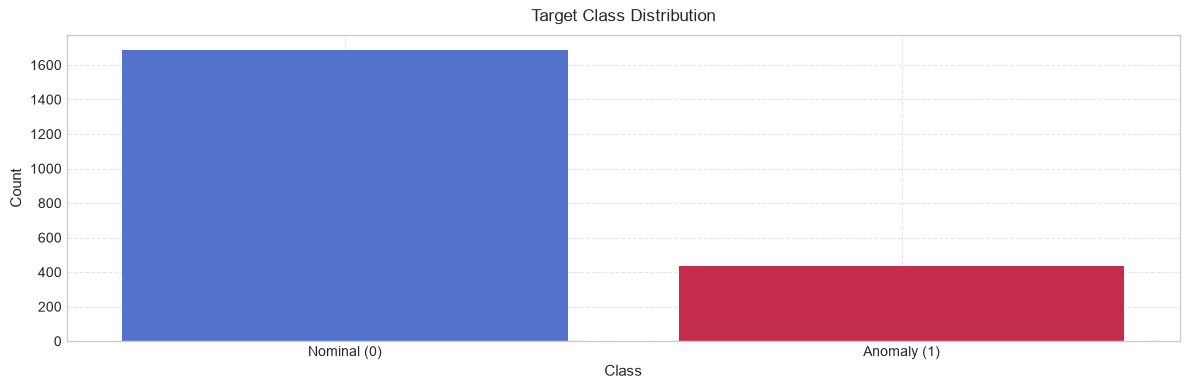

Train and Test Split analysis
Total samples: 2123
Unique values: 2

Value Counts:
train
1    1594
0     529
Name: count, dtype: int64

Percentages:
train
1    75.082431
0    24.917569
Name: proportion, dtype: float64


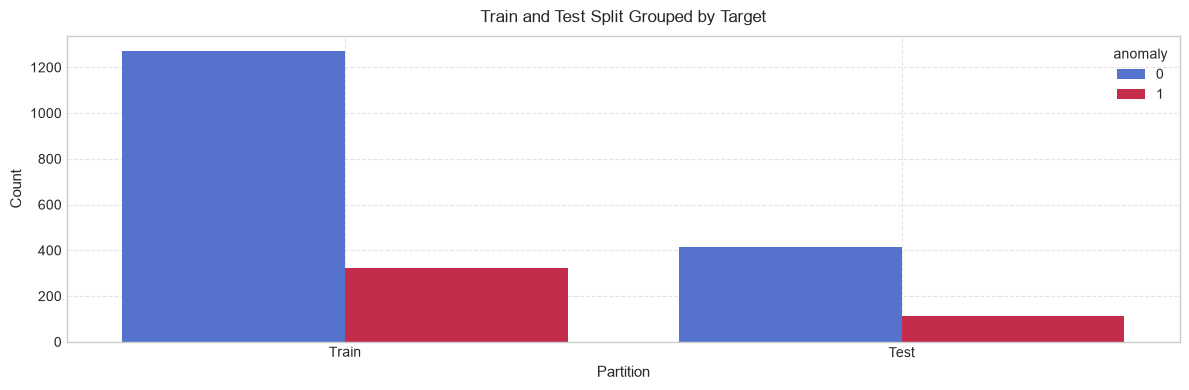

Telemetry Channels analysis
Total samples: 2123
Unique values: 9

Value Counts:
channel
CADC0873    593
CADC0872    546
CADC0888    252
CADC0892    211
CADC0874    194
CADC0884    158
CADC0894    144
CADC0890     14
CADC0886     11
Name: count, dtype: int64

Percentages:
channel
CADC0873    27.932171
CADC0872    25.718323
CADC0888    11.869995
CADC0892     9.938766
CADC0874     9.138012
CADC0884     7.442299
CADC0894     6.782854
CADC0890     0.659444
CADC0886     0.518135
Name: proportion, dtype: float64


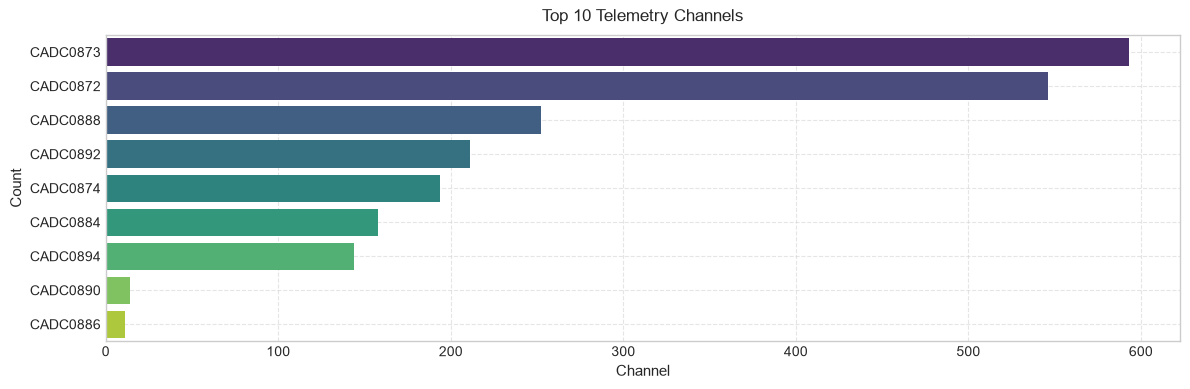

In [16]:
compute_column_statistics(df_dataset, 'anomaly', 'Target Class Distribution')
generate_property_plot(df_dataset, 'anomaly', 'Target Class Distribution', plot_type='count', labels=['Nominal (0)', 'Anomaly (1)'], xlabel="Class")

compute_column_statistics(df_dataset, 'train', 'Train and Test Split')
generate_property_plot(df_dataset, 'train', 'Train and Test Split Grouped by Target', plot_type='count', hue_col='anomaly', order=[1, 0], labels=['Train', 'Test'], xlabel="Partition")

compute_column_statistics(df_dataset, 'channel', 'Telemetry Channels')
generate_property_plot(df_dataset, 'channel', 'Top 10 Telemetry Channels', plot_type='bar_horizontal')

### Advanced Time-Series Profiling

Moving to the high-resolution time-series, we first investigate the temporal sampling interval ($\Delta t$) to assess data continuity. We observe that while the median sampling rate is $1.0$ second, the series contains over $90,000$ sampling gaps—reaching up to $130$ seconds—confirming that time steps are not strictly uniform and that continuous segments must be handled carefully.

We then evaluate the length distribution of these continuous segments across classes to see if anomalous behavior correlates with sequence duration. We notice that segment lengths average $143$ time steps, but anomalous segments exhibit a noticeably wider spread and a higher mean length ($231$ steps) compared to nominal ones ($120$ steps), reaching maximum sequence lengths of up to $1,040$ consecutive points.

In [17]:
def analyze_time_delta_and_gaps(df_seg):
    df_copy = df_seg.copy()
    df_copy['delta_t'] = df_copy.groupby(['channel', 'segment'])['timestamp'].diff().dt.total_seconds()
    
    print("Temporal sampling and Gap analysis")
    print(f"Average Delta-T: {df_copy['delta_t'].mean():.4f} seconds")
    print(f"Median Delta-T:  {df_copy['delta_t'].median():.4f} seconds")
    print(f"Min Delta-T:     {df_copy['delta_t'].min():.4f} seconds")
    print(f"Max Delta-T:     {df_copy['delta_t'].max():.4f} seconds")
    
    gaps = df_copy[df_copy['delta_t'] > 1.0]
    print(f"\nTotal sampling gaps detected (> 1.0s): {len(gaps)}")
    print("\nTop 5 Sampling Intervals Frequencies:")
    print(df_copy['delta_t'].value_counts().head(5))

    delta_subset = df_copy['delta_t'].dropna()
    delta_subset = delta_subset[(delta_subset >= 0) & (delta_subset <= 10)]

    plt.figure()
    ax = sns.histplot(
        delta_subset,
        discrete=True,
        color='royalblue',
        edgecolor='black',
        alpha=0.7
    )
    
    plt.title("Sampling Interval ($\Delta t$) Distribution (0 - 10s)", fontsize=12, pad=10)
    plt.xlabel("Seconds between consecutive samples ($\Delta t$)")
    plt.ylabel("Frequency (Number of Samples)")
    plt.xticks(range(0, 11))
    plt.xlim(-0.6, 10.6)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.grid(True, linestyle='--', alpha=0.5, axis='y')  # Grid solo orizzontale per maggiore pulizia
    plt.tight_layout()
    plt.show()

def analyze_segment_lengths(df_seg):

    seg_lengths = df_seg.groupby(['channel', 'segment', 'anomaly']).size().reset_index(name='point_count')
    
    print("Segment length statistics")
    print(f"Total Segments: {len(seg_lengths)}")
    print(f"Average points per segment: {seg_lengths['point_count'].mean():.2f}")
    print(f"Min points in a segment:    {seg_lengths['point_count'].min()}")
    print(f"Max points in a segment:    {seg_lengths['point_count'].max()}")
    print("\nSequence Length Summary by Class:")
    print(seg_lengths.groupby('anomaly')['point_count'].describe())

    plt.figure()
    sns.boxplot(data=seg_lengths, x='anomaly', y='point_count', hue='anomaly', palette=['royalblue', 'crimson'], legend=False)
    plt.gca().set_xticks([0, 1])
    plt.gca().set_xticklabels(['Nominal (0)', 'Anomaly (1)'])
    plt.title("Sequence Length Distribution per Segment by Class", fontsize=12)
    plt.xlabel("Class")
    plt.ylabel("Number of Time Steps")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Temporal sampling and Gap analysis
Average Delta-T: 1.8876 seconds
Median Delta-T:  1.0000 seconds
Min Delta-T:     0.0000 seconds
Max Delta-T:     130.0000 seconds

Total sampling gaps detected (> 1.0s): 91951

Top 5 Sampling Intervals Frequencies:
delta_t
1.0    187304
5.0     63680
2.0     26941
0.0     22115
6.0       693
Name: count, dtype: int64


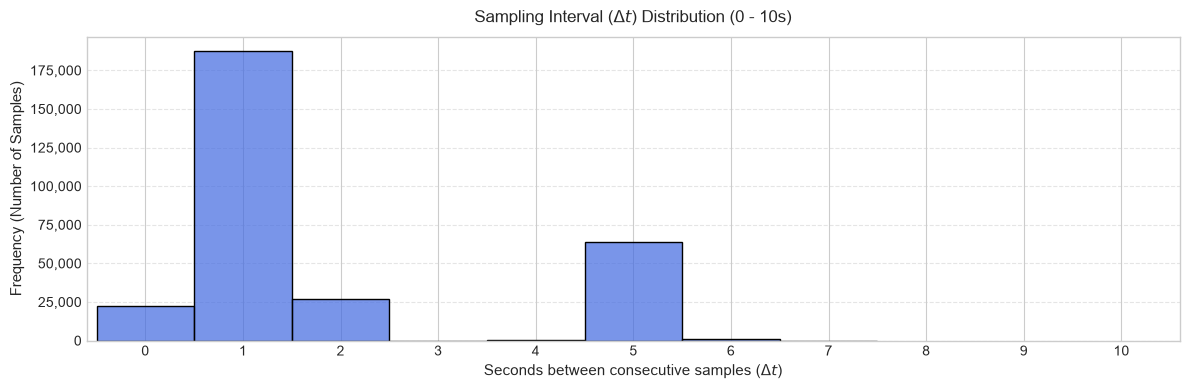

Segment length statistics
Total Segments: 2123
Average points per segment: 142.95
Min points in a segment:    8
Max points in a segment:    1040

Sequence Length Summary by Class:
          count        mean         std   min    25%    50%    75%     max
anomaly                                                                   
0        1689.0  120.325044  131.655155   8.0  35.00   54.0  184.0   827.0
1         434.0  231.023041  190.722243  10.0  61.25  184.5  354.5  1040.0


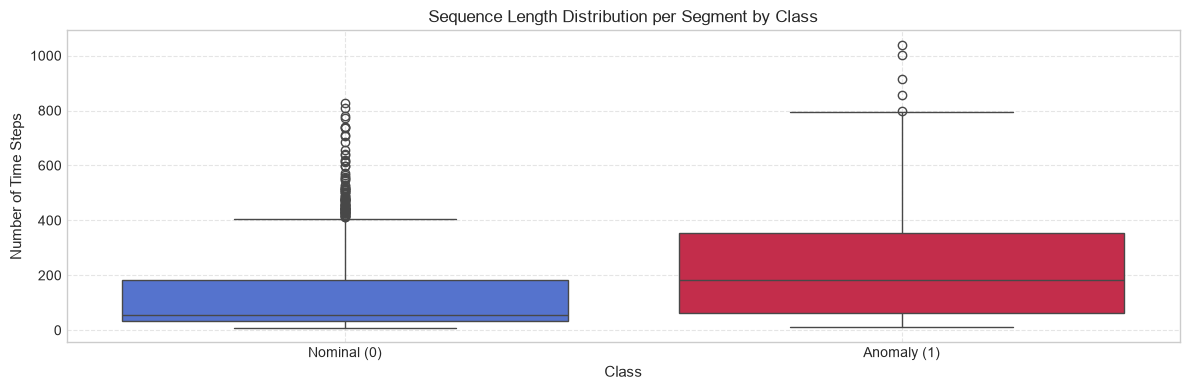

In [18]:
analyze_time_delta_and_gaps(df_segments)
analyze_segment_lengths(df_segments)

## 4. Data normalization pipeline

### 4.1 Channel-Wise Normalization Pipeline

To filter a bit the dataset, we begin by establishing a channel-wise normalization pipeline to standardize telemetry readings across heterogeneous sensors while rigorously preventing data leakage. To ensure that anomalous behavior and test-set dynamics do not distort the feature space, we fit a dedicated StandardScaler for each telemetry channel using exclusively nominal training samples (`train == 1` and `anomaly == 0`). The fitted transformations are then applied uniformly across all segments within their respective channels, producing the standardized feature value_scaled ($Z$-score).

In [19]:
def fit_and_apply_scalers(df_seg, feature_col='value', scaler_type='standard'):

    df_scaled = df_seg.copy()
    df_scaled[f'{feature_col}_scaled'] = np.nan
    
    scalers_dict = {}
    channels = df_seg['channel'].unique()
    
    print(f"Normalization pipeline ({scaler_type} scaler)")
    
    for ch in channels:
        train_nominal_mask = (df_seg['channel'] == ch) & (df_seg['train'] == 1) & (df_seg['anomaly'] == 0)
        channel_mask = (df_seg['channel'] == ch)
        
        train_nominal_vals = df_seg.loc[train_nominal_mask, [feature_col]].values
        
        if len(train_nominal_vals) == 0:
            print(f"Warning: No nominal training samples found for channel {ch}. Skipping.")
            continue

        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler(feature_range=(-1, 1))
        else:
            raise ValueError("Unsupported scaler type. Choose 'standard' or 'minmax'.")

        scaler.fit(train_nominal_vals)
        scalers_dict[ch] = scaler

        all_channel_vals = df_seg.loc[channel_mask, [feature_col]].values
        df_scaled.loc[channel_mask, f'{feature_col}_scaled'] = scaler.transform(all_channel_vals)
        
        print(f"Channel {ch:<10} | Fit Samples (Train Nominal): {len(train_nominal_vals):<6} | Mean: {scaler.mean_[0]:8.4f} | Std: {np.sqrt(scaler.var_[0]):8.4f}")
        
    print("\nNormalization complete. Scaled feature added: 'value_scaled'")
    
    return df_scaled, scalers_dict

df_segments_clean, channel_scalers = fit_and_apply_scalers(df_segments, feature_col='value', scaler_type='standard')
display(df_segments_clean[['channel', 'timestamp', 'value', 'value_scaled', 'anomaly', 'train']].head())

Normalization pipeline (standard scaler)
Channel CADC0872   | Fit Samples (Train Nominal): 32718  | Mean:   0.0000 | Std:   0.0000
Channel CADC0873   | Fit Samples (Train Nominal): 35404  | Mean:  -0.0000 | Std:   0.0000
Channel CADC0874   | Fit Samples (Train Nominal): 17880  | Mean:   0.0000 | Std:   0.0000
Channel CADC0884   | Fit Samples (Train Nominal): 9121   | Mean:   0.4715 | Std:   0.3883
Channel CADC0886   | Fit Samples (Train Nominal): 190    | Mean:   0.1743 | Std:   0.2256
Channel CADC0888   | Fit Samples (Train Nominal): 6446   | Mean:   0.2815 | Std:   0.3562
Channel CADC0890   | Fit Samples (Train Nominal): 147    | Mean:   0.3697 | Std:   0.3839
Channel CADC0892   | Fit Samples (Train Nominal): 30936  | Mean:   0.2700 | Std:   0.3437
Channel CADC0894   | Fit Samples (Train Nominal): 20857  | Mean:   0.1314 | Std:   0.2273

Normalization complete. Scaled feature added: 'value_scaled'


,channel,timestamp,value,value_scaled,anomaly,train
0,CADC0872,2022-06-01 23:42:54+00:00,-0.000021,-1.010056,1,1
1,CADC0872,2022-06-01 23:42:55+00:00,-0.000021,-0.965855,1,1
2,CADC0872,2022-06-01 23:42:56+00:00,-0.000021,-0.990932,1,1
3,CADC0872,2022-06-01 23:42:57+00:00,-0.000021,-1.009889,1,1
4,CADC0872,2022-06-01 23:42:58+00:00,-0.000021,-1.009889,1,1


### 4.2 Density Distribution Analysis

Next, we inspect the per-channel density distributions before and after standardization to evaluate the impact of the pipeline. We observe that raw values vary across drastically different numerical ranges—from sub-zero micro-fluctuations in `CADC0872` to positive offsets exceeding $1.5$ in `CADC0884`. Following $Z$-score normalization, all channels are successfully mapped onto a shared zero-mean, unit-variance baseline for nominal operation. Finally, comparing the aggregated global distributions demonstrates how standardizing per channel aligns all sensors into a well-behaved, zero-centered feature space, isolating anomalous deviations into clear distribution tails suitable for sequence modeling.

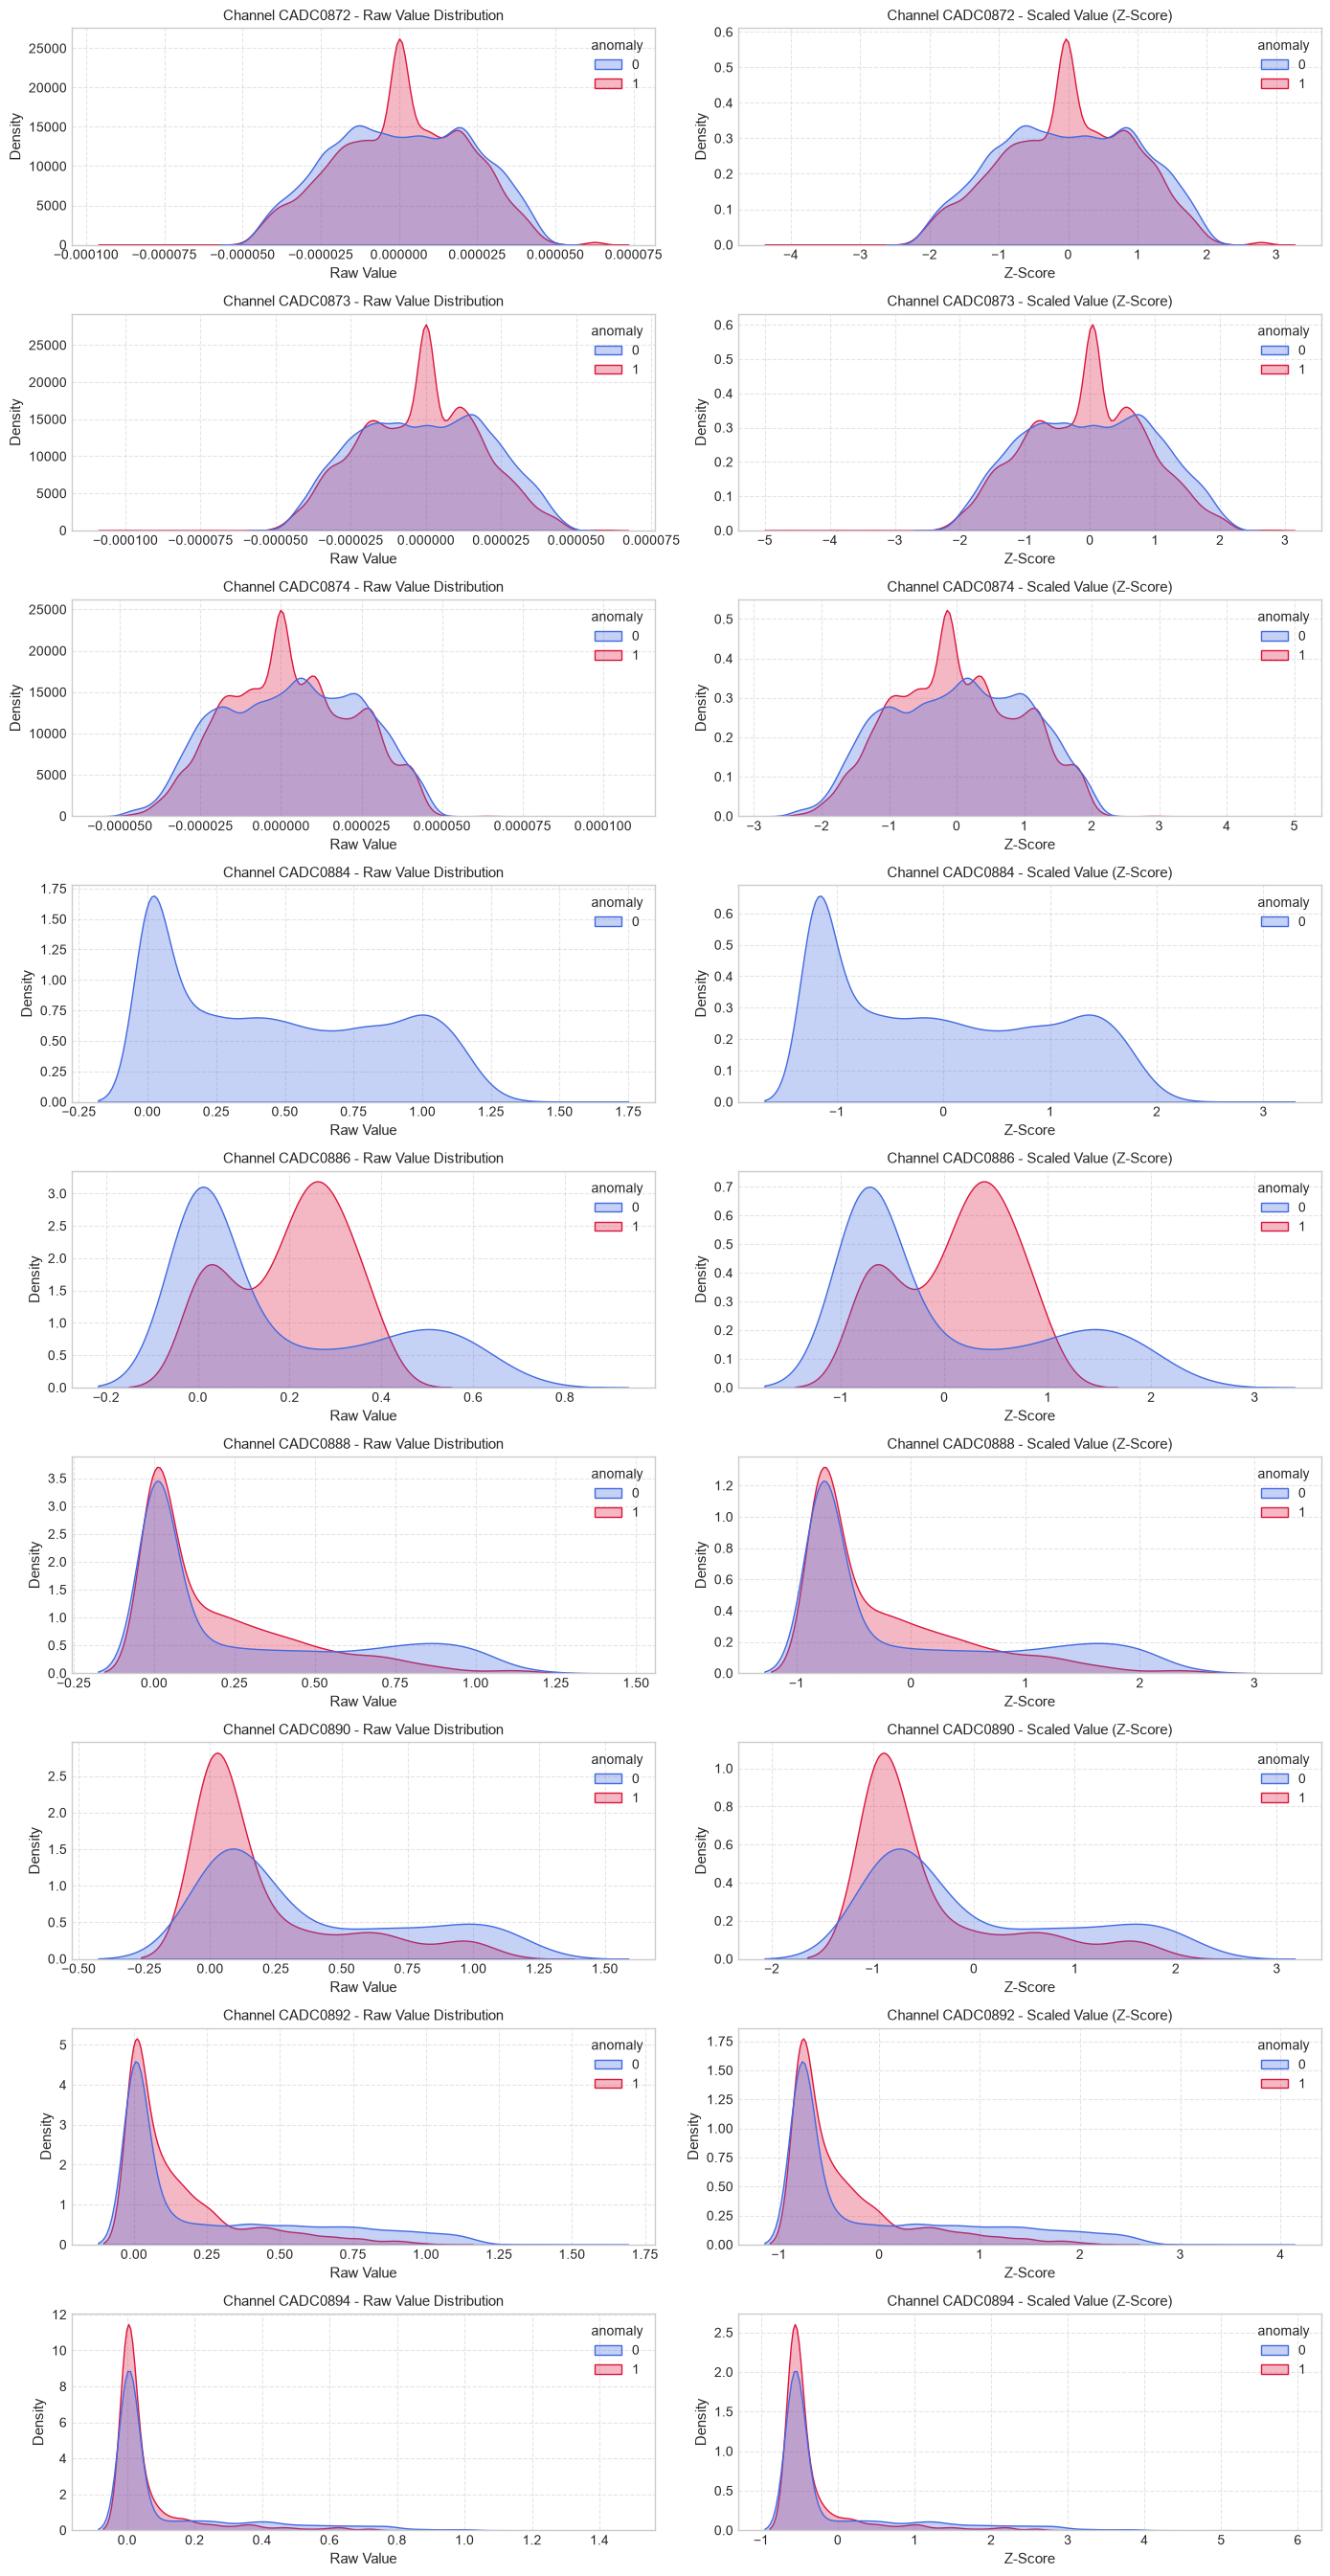

In [20]:
channels = df_segments_clean['channel'].unique()
fig, axes = plt.subplots(len(channels), 2, figsize=(14, 3 * len(channels)))

color_dict = {0: 'royalblue', 1: 'crimson'}

for i, ch in enumerate(channels):
    ch_df = df_segments_clean[df_segments_clean['channel'] == ch]

    sns.kdeplot(
        data=ch_df, x='value', hue='anomaly', ax=axes[i, 0], 
        palette=color_dict, common_norm=False, fill=True, alpha=0.3
    )
    axes[i, 0].set_title(f"Channel {ch} - Raw Value Distribution", fontsize=11)
    axes[i, 0].set_xlabel("Raw Value")
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)

    sns.kdeplot(
        data=ch_df, x='value_scaled', hue='anomaly', ax=axes[i, 1], 
        palette=color_dict, common_norm=False, fill=True, alpha=0.3
    )
    axes[i, 1].set_title(f"Channel {ch} - Scaled Value (Z-Score)", fontsize=11)
    axes[i, 1].set_xlabel("Z-Score")
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

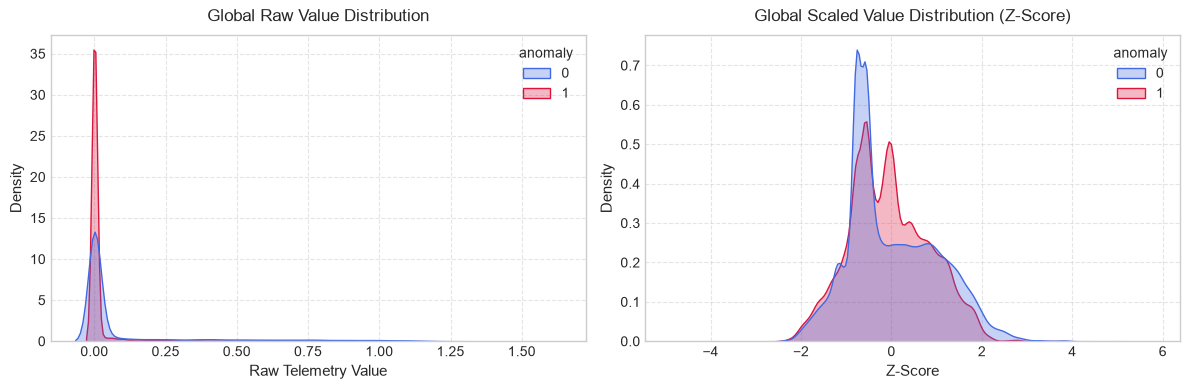

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_dict = {0: 'royalblue', 1: 'crimson'}

sns.kdeplot(
    data=df_segments_clean, 
    x='value', 
    hue='anomaly', 
    ax=axes[0], 
    palette=color_dict, 
    common_norm=False, 
    fill=True, 
    alpha=0.3
)
axes[0].set_title("Global Raw Value Distribution", fontsize=12, pad=10)
axes[0].set_xlabel("Raw Telemetry Value", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.kdeplot(
    data=df_segments_clean, 
    x='value_scaled', 
    hue='anomaly', 
    ax=axes[1], 
    palette=color_dict, 
    common_norm=False, 
    fill=True, 
    alpha=0.3
)
axes[1].set_title("Global Scaled Value Distribution (Z-Score)", fontsize=12, pad=10)
axes[1].set_xlabel("Z-Score", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Advanced Time-Series Analysis & Spectral Profiling

### 5.1 Time-Series Visual Inspection with Anomaly Highlighting

We begin by plotting a window of the standardized telemetry signal to visually inspect point-wise temporal patterns and anomaly distributions. We observe that nominal sequences exhibit smooth, periodic oscillations characteristic of orbital cycles, whereas anomalous regions introduce abrupt regime shifts, sudden spikes, or persistent offset dislocations.

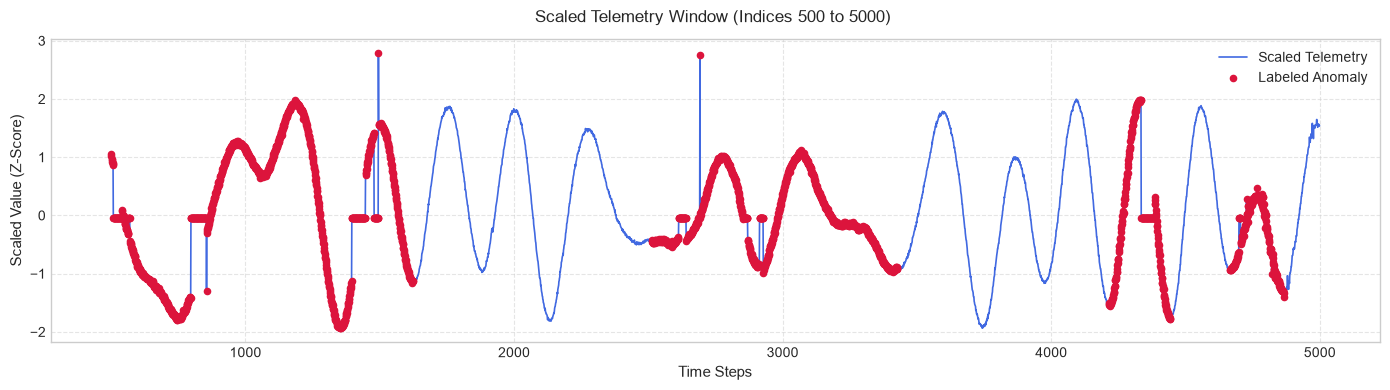

Window Statistics (indices 500-5000):
Nominal points (0): 2031
Anomalous points (1): 2469



In [22]:
def plot_telemetry_signal(df, column='value_scaled', target_col='anomaly', start=0, end=2000, title_suffix=""):

    if column not in df.columns:
        print(f"Error: Column '{column}' not found.")
        return

    sub_df = df.iloc[start:end].copy()
    plt.figure(figsize=(14, 4))
    plt.plot(range(start, end), sub_df[column].values, color='royalblue', linewidth=1.2, label='Scaled Telemetry')

    anomaly_mask = (sub_df[target_col] == 1).values
    anomaly_indices = np.where(anomaly_mask)[0] + start
    
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_indices, df[column].iloc[anomaly_indices].values, color='crimson', s=20, zorder=3, label='Labeled Anomaly')
        
    plt.title(f"Scaled Telemetry Window (Indices {start} to {end}) {title_suffix}", fontsize=12, pad=12)
    plt.xlabel("Time Steps", fontsize=11)
    plt.ylabel("Scaled Value (Z-Score)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print(f"Window Statistics (indices {start}-{end}):")
    print(f"Nominal points (0): {(sub_df[target_col] == 0).sum()}")
    print(f"Anomalous points (1): {(sub_df[target_col] == 1).sum()}\n")

plot_telemetry_signal(df_segments_clean, column='value_scaled', start=500, end=5000)

### 5.2 Stationarity, Autocorrelation, and Memory Profiling

We next evaluate the statistical properties and temporal dependencies of single telemetry segments. Applying the Augmented Dickey-Fuller (ADF) test on a representative segment yields a high $p$-value ($> 0.05$), failing to reject the null hypothesis and confirming non-stationary behavior driven by low-frequency trends. Examining the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) reveals a slow, gradual decay in autocorrelation over multiple lags, demonstrating strong temporal memory and underscoring the need for sequence models capable of capturing long-term historical context

Augmented Dickey-Fuller test (Segment 1)
ADF Statistic: -0.793793
p-value:       8.209386e-01
Critical Values:
   1% : -3.4555
   5% : -2.8726
   10%: -2.5727
Conclusion: The sequence is non-stationary (p-value > 0.05).


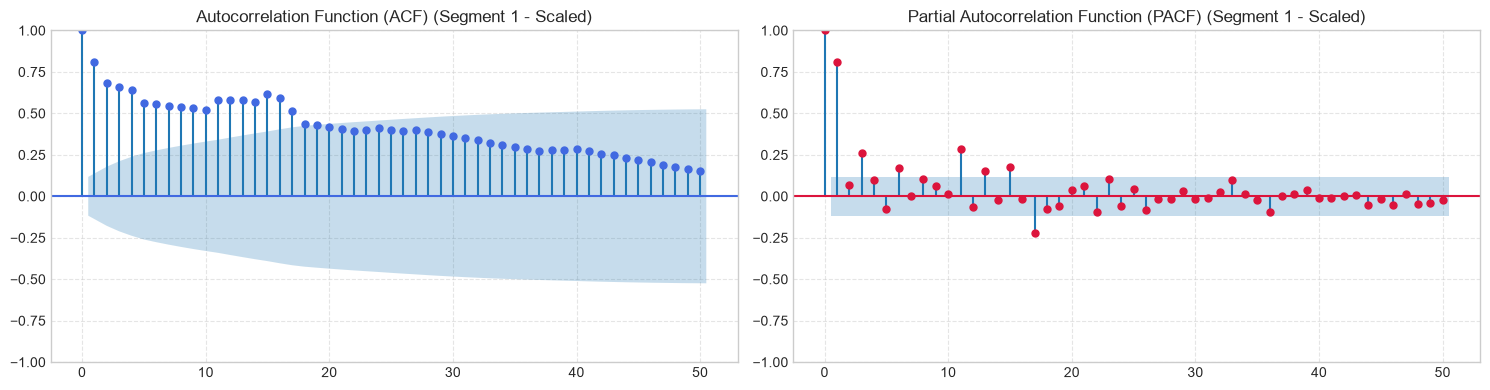

In [23]:
def check_segment_stationarity(series, segment_id=1):

    clean_series = series.dropna()
    result = adfuller(clean_series)
    
    print(f"Augmented Dickey-Fuller test (Segment {segment_id})")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value:       {result[1]:.6e}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key:<3}: {value:.4f}")
        
    if result[1] < 0.05:
        print("Conclusion: The sequence is stationary (p-value < 0.05).")
    else:
        print("Conclusion: The sequence is non-stationary (p-value > 0.05).")

def plot_signal_autocorrelation(series, lags=50, title=""):

    clean_series = series.dropna()
    _, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    plot_acf(clean_series, lags=lags, ax=axes[0], color='royalblue', alpha=0.05)
    axes[0].set_title(f"Autocorrelation Function (ACF) {title}", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    plot_pacf(clean_series, lags=lags, ax=axes[1], color='crimson', alpha=0.05)
    axes[1].set_title(f"Partial Autocorrelation Function (PACF) {title}", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

sample_segment = df_segments_clean[df_segments_clean['segment'] == 1]['value_scaled']

check_segment_stationarity(sample_segment, segment_id=1)
plot_signal_autocorrelation(sample_segment, lags=50, title="(Segment 1 - Scaled)")

### 5.3 Frequency Domain Analysis (FFT Spectrum)

Finally, we transform continuous nominal and anomalous sequence blocks into the frequency domain via Fast Fourier Transform (FFT) to analyze their spectral signatures. Comparing equal-length continuous segments ($N=250$), we observe that nominal operations concentrate energy predominantly in low-frequency fundamental components associated with periodic orbital dynamics. In contrast, anomalous regimes introduce significant high-frequency noise and broader spectral energy distribution, indicating high-frequency distortions that serve as strong discriminative features for anomaly detection.

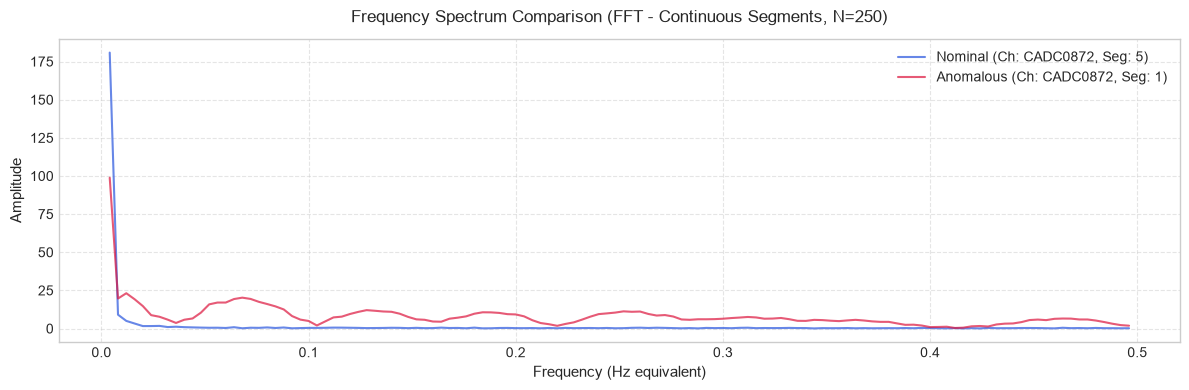

In [24]:
def plot_comparative_fft(df, window_size=250):
    nom_candidates = (
        df[df['anomaly'] == 0]
        .groupby(['channel', 'segment'])
        .size()
        .loc[lambda x: x >= window_size]
    )
    
    anom_candidates = (
        df[df['anomaly'] == 1]
        .groupby(['channel', 'segment'])
        .size()
        .loc[lambda x: x >= window_size]
    )

    if len(nom_candidates) == 0 or len(anom_candidates) == 0:
        print(f"Warning: Impossible to find continuous segments with length >= {window_size}.")
        return

    nom_seg_id = nom_candidates.index[0]
    anom_seg_id = anom_candidates.index[0]

    nominal_sub = df[(df['channel'] == nom_seg_id[0]) & (df['segment'] == nom_seg_id[1])]['value_scaled'].values[:window_size]
    anomalous_sub = df[(df['channel'] == anom_seg_id[0]) & (df['segment'] == anom_seg_id[1])]['value_scaled'].values[:window_size]

    fft_nom = fft(nominal_sub)
    freq_nom = fftfreq(window_size, d=1.0)
    pos_mask_nom = freq_nom > 0

    fft_anom = fft(anomalous_sub)
    freq_anom = fftfreq(window_size, d=1.0)
    pos_mask_anom = freq_anom > 0

    plt.figure(figsize=(12, 4))
    plt.plot(freq_nom[pos_mask_nom], np.abs(fft_nom)[pos_mask_nom], color='royalblue', linewidth=1.5, label=f'Nominal (Ch: {nom_seg_id[0]}, Seg: {nom_seg_id[1]})', alpha=0.8)
    plt.plot(freq_anom[pos_mask_anom], np.abs(fft_anom)[pos_mask_anom], color='crimson', linewidth=1.5, label=f'Anomalous (Ch: {anom_seg_id[0]}, Seg: {anom_seg_id[1]})', alpha=0.7)

    plt.title(f"Frequency Spectrum Comparison (FFT - Continuous Segments, N={window_size})", fontsize=12, pad=12)
    plt.xlabel("Frequency (Hz equivalent)", fontsize=11)
    plt.ylabel("Amplitude", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_comparative_fft(df_segments_clean, window_size=250)

## 6. Sequence Formatting & Sliding Window Generation for Deep Learning Models

### 6.1 Sliding Window Generation Function

We partition the training segments to create an independent validation set while preventing data leakage. Rather than splitting randomly across individual time steps, we randomly sample $20\%$ of unique segment IDs from the training set (`train == 1`) to form the validation subset, ensuring that continuous temporal sequences remain intact within a single split.

In [25]:
def create_sliding_windows(df, mode="cnn", feature_col="value_scaled", window_size=50, stride=1):

    X_list = []
    y_list = []
    meta_list = []

    grouped = df.groupby(["channel", "segment"])
    
    for (ch, seg), group in grouped:
        values = group[feature_col].values
        labels = group["anomaly"].values
        n_points = len(values)
        
        if n_points < window_size:
            continue
            
        for start_idx in range(0, n_points - window_size + 1, stride):
            end_idx = start_idx + window_size
            window_vals = values[start_idx:end_idx]

            if mode == "cnn":
                window_label = labels[end_idx - 1]
            elif mode == "tranad":
                window_label = labels[start_idx:end_idx]
            else:
                raise ValueError(f"Unknown mode: {mode}")
            
            X_list.append(window_vals)
            y_list.append(window_label)
            meta_list.append({"channel": ch, "segment": seg, "start_idx": start_idx})
            
    X_array = np.array(X_list)[..., np.newaxis]
    y_array = np.array(y_list)
    
    return X_array, y_array, pd.DataFrame(meta_list)

### 6.2 Preprocessed Data Export

Next, we format the continuous 1D time-series into 3D tensors suitable for deep learning sequence architectures using a sliding window algorithm ($W=50$, $S=1$). For each continuous segment, fixed-length windows are extracted along with a binary window label, set to $1$ if at least one anomalous sample exists within the sequence window. Short segments below the window size ($< 50$ steps) are discarded, resulting in structured 3D feature arrays $(N, W, D)$ and aligned label vectors across the train, validation, and test partitions.

In [26]:
WINDOW_SIZE = 50

df_train_full = df_segments_clean[df_segments_clean['train'] == 1].copy()
df_test       = df_segments_clean[df_segments_clean['train'] == 0].copy()

unique_train_segments = df_train_full[['channel', 'segment']].drop_duplicates()
val_segments = unique_train_segments.sample(frac=0.20, random_state=SEED)
is_val = df_train_full.set_index(['channel', 'segment']).index.isin(val_segments.set_index(['channel', 'segment']).index)

df_train = df_train_full[~is_val].copy()
df_val   = df_train_full[is_val].copy()

print("\nGenerating CNN-1D Datasets...")
X_train_cnn, y_train_cnn, _ = create_sliding_windows(df_train, mode="cnn", window_size=WINDOW_SIZE, stride=5)
X_val_cnn,   y_val_cnn, _   = create_sliding_windows(df_val,   mode="cnn", window_size=WINDOW_SIZE, stride=1)
X_test_cnn,  y_test_cnn, _  = create_sliding_windows(df_test,  mode="cnn", window_size=WINDOW_SIZE, stride=1)

np.save(os.path.join(PROCESSED_DATA_DIR, f"X_train_cnn_w{WINDOW_SIZE}.npy"), X_train_cnn)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_train_cnn_w{WINDOW_SIZE}.npy"), y_train_cnn)
np.save(os.path.join(PROCESSED_DATA_DIR, f"X_val_cnn_w{WINDOW_SIZE}.npy"),   X_val_cnn)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_val_cnn_w{WINDOW_SIZE}.npy"),   y_val_cnn)
np.save(os.path.join(PROCESSED_DATA_DIR, f"X_test_cnn_w{WINDOW_SIZE}.npy"),  X_test_cnn)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_test_cnn_w{WINDOW_SIZE}.npy"),  y_test_cnn)

print("\nGenerating TranAD Datasets...")
X_train_tranad, y_train_tranad, _ = create_sliding_windows(df_train, mode="tranad", window_size=WINDOW_SIZE, stride=1)
X_val_tranad,   y_val_tranad, _   = create_sliding_windows(df_val,   mode="tranad", window_size=WINDOW_SIZE, stride=1)
X_test_tranad,  y_test_tranad, _  = create_sliding_windows(df_test,  mode="tranad", window_size=WINDOW_SIZE, stride=1)

np.save(os.path.join(PROCESSED_DATA_DIR, f"X_train_tranad_w{WINDOW_SIZE}.npy"), X_train_tranad)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_train_tranad_w{WINDOW_SIZE}.npy"), y_train_tranad)
np.save(os.path.join(PROCESSED_DATA_DIR, f"X_val_tranad_w{WINDOW_SIZE}.npy"),   X_val_tranad)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_val_tranad_w{WINDOW_SIZE}.npy"),   y_val_tranad)
np.save(os.path.join(PROCESSED_DATA_DIR, f"X_test_tranad_w{WINDOW_SIZE}.npy"),  X_test_tranad)
np.save(os.path.join(PROCESSED_DATA_DIR, f"y_test_tranad_w{WINDOW_SIZE}.npy"),  y_test_tranad)

print("\nDatasets generated and saved successfully.")


Generating CNN-1D Datasets...

Generating TranAD Datasets...

Datasets generated and saved successfully.
